# EDA Interacciones con Soporte

## Introducción

En este análisis exploratorio se estudiará el comportamiento de las interacciones de soporte de los clientes.

El objetivo es identificar patrones relacionados con:
- canales de contacto,
- motivos de interacción,
- satisfacción del cliente,
- incidencias,
- tiempos de resolución,
- y posibles señales relacionadas con churn.

## Librerías

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## Carga de datos

Cargamos el dataset de interacciones con soporte y realizamos una primera inspección de su estructura.

In [3]:
path_soporte = r'C:\Users\cunat\Desktop\GIT\UCV-Churn\data\raw\interacciones_soporte.csv'

soporte = pd.read_csv(path_soporte)

print('interacciones_soporte:', soporte.shape)

display(soporte.head())

interacciones_soporte: (308487, 13)


,interaccion_id,cliente_id,fecha_evento,mes,canal,motivo,duracion_min,resuelto,satisfaccion_post,stress_calidad_lag,incidencia_masiva_lag,impago_mes,dias_retraso_mes
0,I923052492930,C000001,2023-02-07,2023-02-01,telefono,Facturación,9.5,0,4.0,0.4104,0,0,0
1,I692361171059,C000001,2023-04-20,2023-04-01,app_chat,Facturación,3.9,1,4.0,0.4301,0,0,0
2,I354109146175,C000001,2023-04-27,2023-04-01,app_chat,Baja / portabilidad,2.8,1,5.0,0.4301,0,0,0
3,I986032353420,C000001,2023-05-04,2023-05-01,telefono,Consulta general,8.4,1,3.0,0.4486,0,0,0
4,I553023863181,C000001,2023-06-26,2023-06-01,telefono,Impago / pago,4.5,1,4.0,0.3936,0,0,0


### Relación entre interacciones de soporte y churn

El dataset `interacciones_soporte.csv` tampoco vive en el mismo nivel que `churn_target.csv`.

- `interacciones_soporte.csv` tiene múltiples filas por cliente, ya que un mismo cliente puede contactar varias veces con soporte.
- `churn_target.csv` tiene una estructura temporal cliente-mes.

Por tanto, no es correcto realizar una unión directa y tratar ambos datasets como si representaran el mismo nivel analítico.

Para este EDA construiremos una etiqueta agregada por cliente:

- `ever_churn = 1` si el cliente churnea al menos una vez durante el periodo observado.
- `ever_churn = 0` en caso contrario.

Esto permitirá analizar si determinados patrones de soporte:
- mayor número de interacciones,
- incidencias repetidas,
- baja satisfacción,
- contactos por baja o portabilidad,
- o problemas de facturación

aparecen con más frecuencia en clientes que terminan abandonando.

Sin embargo, esta aproximación tiene una limitación importante:
la dimensión temporal queda agregada en una única etiqueta.

Por tanto, este enfoque es útil para exploración y análisis descriptivo, pero no sustituye un modelado temporal riguroso orientado a predicción de churn.

In [4]:
# ==========================================
# Cargar churn_target
# ==========================================

path_churn = r'C:\Users\cunat\Desktop\GIT\UCV-Churn\data\raw\churn_target.csv'

churn = pd.read_csv(path_churn)

print('churn_target:', churn.shape)

display(churn.head())

churn_target: (321987, 3)


,cliente_id,fecha,churn
0,C000001,2023-01-01,0
1,C000001,2023-02-01,0
2,C000001,2023-03-01,0
3,C000001,2023-04-01,0
4,C000001,2023-05-01,0


In [5]:
# ==========================================
# Construcción variable ever_churn
# ==========================================

ever_churn = (
    churn
    .groupby('cliente_id')['churn']
    .max()
    .reset_index()
)

ever_churn = ever_churn.rename(
    columns={'churn': 'ever_churn'}
)

display(ever_churn.head())

,cliente_id,ever_churn
0,C000001,0
1,C000002,0
2,C000003,1
3,C000004,0
4,C000005,0


In [6]:
# ==========================================
# Unión con interacciones soporte
# ==========================================

soporte_churn = soporte.merge(
    ever_churn,
    on='cliente_id',
    how='left'
)

print(soporte_churn.shape)

display(soporte_churn.head())

(308487, 14)


,interaccion_id,cliente_id,fecha_evento,mes,canal,motivo,duracion_min,resuelto,satisfaccion_post,stress_calidad_lag,incidencia_masiva_lag,impago_mes,dias_retraso_mes,ever_churn
0,I923052492930,C000001,2023-02-07,2023-02-01,telefono,Facturación,9.5,0,4.0,0.4104,0,0,0,0
1,I692361171059,C000001,2023-04-20,2023-04-01,app_chat,Facturación,3.9,1,4.0,0.4301,0,0,0,0
2,I354109146175,C000001,2023-04-27,2023-04-01,app_chat,Baja / portabilidad,2.8,1,5.0,0.4301,0,0,0,0
3,I986032353420,C000001,2023-05-04,2023-05-01,telefono,Consulta general,8.4,1,3.0,0.4486,0,0,0,0
4,I553023863181,C000001,2023-06-26,2023-06-01,telefono,Impago / pago,4.5,1,4.0,0.3936,0,0,0,0


In [7]:
# ==========================================
# Distribución churn
# ==========================================

soporte_churn['ever_churn'] \
    .value_counts()

ever_churn
0    269735
1     38752
Name: count, dtype: int64

In [8]:
(
    soporte_churn['ever_churn']
    .value_counts(normalize=True) * 100
)

ever_churn
0    87.438044
1    12.561956
Name: proportion, dtype: float64

## 3. Preprocesamiento y limpieza de datos

### 3.1 Conversión de tipos


In [20]:
# ==========================================
# Conversión de fechas
# ==========================================

soporte_churn['fecha_evento'] = pd.to_datetime(
    soporte_churn['fecha_evento'],
    format='mixed'
)

soporte_churn['mes'] = pd.to_datetime(
    soporte_churn['mes'],
    format='mixed'
)

In [21]:
# ==========================================
# Información general
# ==========================================

soporte_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308487 entries, 0 to 308486
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   interaccion_id         308487 non-null  object        
 1   cliente_id             308487 non-null  object        
 2   fecha_evento           308487 non-null  datetime64[ns]
 3   mes                    308487 non-null  datetime64[ns]
 4   canal                  308487 non-null  object        
 5   motivo                 303847 non-null  object        
 6   duracion_min           308487 non-null  float64       
 7   resuelto               308487 non-null  int64         
 8   satisfaccion_post      303858 non-null  float64       
 9   stress_calidad_lag     308487 non-null  float64       
 10  incidencia_masiva_lag  308487 non-null  int64         
 11  impago_mes             308487 non-null  int64         
 12  dias_retraso_mes       308487 non-null  int6

### 3.2 Detección de duplicados


In [22]:
# ==========================================
# Duplicados
# ==========================================

print(
    'Duplicados:',
    soporte_churn.duplicated().sum()
)

Duplicados: 4558


In [23]:
duplicados = soporte_churn[
    soporte_churn.duplicated(keep=False)
]

display(duplicados)

,interaccion_id,cliente_id,fecha_evento,mes,canal,motivo,duracion_min,resuelto,satisfaccion_post,stress_calidad_lag,incidencia_masiva_lag,impago_mes,dias_retraso_mes,ever_churn
212,I716491295118,C000007,2023-06-01,2023-06-01,tienda,Consulta general,13.0,0,2.0,0.3936,0,0,0,0
248,I271008632610,C000008,2023-10-04,2023-10-01,telefono,Cambio de plan,4.1,1,5.0,0.4066,0,0,0,0
255,I831660710653,C000008,2024-04-25,2024-04-01,app_chat,Calidad de señal,8.0,1,3.0,0.2994,0,0,0,0
317,I666962040807,C000010,2025-08-20,2025-08-01,telefono,Consulta general,4.9,0,5.0,0.3991,0,0,0,0
326,I721437122731,C000011,2023-04-14,2023-04-01,telefono,Baja / portabilidad,10.8,0,3.0,0.5407,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308482,I219953166860,C006660,2023-02-10,2023-02-01,app_chat,Consulta general,4.6,1,4.0,0.5550,0,0,0,0
308483,I789637224824,C000256,2025-05-18,2025-05-01,fax,Calidad de señal,4.0,0,2.0,0.6359,0,0,0,0
308484,I587205965908,C007840,2025-04-17,2025-04-01,app_chat,Cobertura / velocidad,9.4,1,5.0,0.3479,0,0,0,0
308485,I318997032637,C004546,2023-02-07,2023-02-01,telefono,Calidad de señal,6.7,0,4.0,0.4093,0,0,0,1


In [24]:
# ==========================================
# Eliminación duplicados
# ==========================================

soporte_churn = soporte_churn.drop_duplicates()

print(soporte_churn.shape)

(303929, 14)


### 3.3 Valores nulos


In [25]:
# ==========================================
# Valores nulos
# ==========================================

soporte_churn.isnull().sum()

interaccion_id              0
cliente_id                  0
fecha_evento                0
mes                         0
canal                       0
motivo                   4558
duracion_min                0
resuelto                    0
satisfaccion_post        4558
stress_calidad_lag          0
incidencia_masiva_lag       0
impago_mes                  0
dias_retraso_mes            0
ever_churn                  0
dtype: int64

In [31]:
pd.crosstab(
    soporte_churn['resuelto'],
    soporte_churn['satisfaccion_post'].isnull(),
    normalize='index'
)

satisfaccion_post,False,True
resuelto,,
0,0.98517,0.01483
1,0.98488,0.01512


In [32]:
pd.crosstab(
    soporte_churn['canal'],
    soporte_churn['motivo'].isnull(),
    normalize='index'
)

motivo,False,True
canal,,
app_chat,0.984982,0.015018
carrier-pigeon,0.991613,0.008387
email,0.985394,0.014606
fax,0.983097,0.016903
paloma,0.980379,0.019621
telefono,0.985002,0.014998
tienda,0.984795,0.015205


Optamos por:

- imputar la categoría `"Desconocido"` en la variable `motivo`,
- y eliminar los registros sin información de `satisfaccion_post`.

In [33]:
# ==========================================
# Motivo nulo
# ==========================================

soporte_churn['motivo'] = soporte_churn[
    'motivo'
].fillna('Desconocido')


# ==========================================
# Eliminar satisfacción nula
# ==========================================

soporte_churn = soporte_churn[
    soporte_churn['satisfaccion_post'].notnull()
]

### 3.4 Validación de inconsistencias


In [26]:
# ==========================================
# Duraciones negativas
# ==========================================

duracion_negativa = soporte_churn[
    soporte_churn['duracion_min'] < 0
]

if duracion_negativa.empty:
    print('No hay duraciones negativas')
else:
    display(duracion_negativa)

,interaccion_id,cliente_id,fecha_evento,mes,canal,motivo,duracion_min,resuelto,satisfaccion_post,stress_calidad_lag,incidencia_masiva_lag,impago_mes,dias_retraso_mes,ever_churn
100,I371216030626,C000003,2025-02-24,2025-02-01,telefono,Impago / pago,-14.1,0,2.0,0.4073,0,1,19,1
109,I631454523770,C000004,2023-07-19,2023-07-01,email,Calidad de señal,-1.0,0,5.0,0.4921,0,0,0,0
170,I596805245857,C000005,2025-07-27,2025-07-01,tienda,Cambio de plan,-4.4,1,4.0,0.3499,0,1,26,0
316,I313815800225,C000010,2025-06-15,2025-06-01,telefono,Facturación,-12.1,1,4.0,0.3831,0,0,0,0
355,I831558959878,C000011,2024-12-03,2024-12-01,app_chat,Cobertura / velocidad,-5.2,1,4.0,0.4301,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
303610,I377213507080,C009991,2023-05-08,2023-05-01,app_chat,Consulta general,-10.1,1,5.0,0.4001,0,0,0,0
303703,I602772070066,C009993,2025-02-25,2025-02-01,tienda,Calidad de señal,-5.0,1,4.0,0.6646,0,0,0,0
303779,I410897605563,C009995,2025-07-03,2025-07-01,app_chat,Baja / portabilidad,-10.3,1,4.0,0.3569,0,0,0,0
303802,I200625231698,C009996,2025-03-20,2025-03-01,telefono,Baja / portabilidad,-2.5,0,2.0,0.3581,0,0,0,0


In [34]:
soporte_churn[
    soporte_churn['duracion_min'] < 0
][
    ['duracion_min', 'satisfaccion_post']
].head()

,duracion_min,satisfaccion_post
100,-14.1,2.0
109,-1.0,5.0
170,-4.4,4.0
316,-12.1,4.0
355,-5.2,4.0


In [35]:
# ==========================================
# Eliminar duraciones negativas
# ==========================================

soporte_churn = soporte_churn[
    soporte_churn['duracion_min'] >= 0
]

print(soporte_churn.shape)

(294876, 14)


Se detectaron `4558` registros con duraciones negativas en la variable `duracion_min`.

Dado que una duración negativa no tiene sentido operativo, estos registros fueron considerados inconsistencias de datos.

Además, se observó que estos casos coincidían frecuentemente con valores faltantes en variables como `satisfaccion_post`, lo que sugiere posibles errores de captura o registros incompletos.

Por tanto, se optó por eliminar dichos registros para evitar distorsiones en el análisis posterior.

In [27]:
# ==========================================
# Satisfacción fuera de rango
# ==========================================

satisfaccion_invalida = soporte_churn[
    (soporte_churn['satisfaccion_post'] < 1) |
    (soporte_churn['satisfaccion_post'] > 5)
]

if satisfaccion_invalida.empty:
    print('No hay valores inválidos en satisfaccion_post')
else:
    display(satisfaccion_invalida)

No hay valores inválidos en satisfaccion_post


In [28]:
# ==========================================
# Días retraso negativos
# ==========================================

retraso_negativo = soporte_churn[
    soporte_churn['dias_retraso_mes'] < 0
]

if retraso_negativo.empty:
    print('No hay días de retraso negativos')
else:
    display(retraso_negativo)

No hay días de retraso negativos


In [29]:
# ==========================================
# Variables binarias
# ==========================================

for col in [
    'resuelto',
    'impago_mes',
    'incidencia_masiva_lag',
    'ever_churn'
]:
    
    print('\n')
    print(col)
    
    display(
        soporte_churn[col]
        .value_counts(dropna=False)
    )



resuelto


resuelto
1    174800
0    129129
Name: count, dtype: int64



impago_mes


impago_mes
0    221711
1     82218
Name: count, dtype: int64



incidencia_masiva_lag


incidencia_masiva_lag
0    301886
1      2043
Name: count, dtype: int64



ever_churn


ever_churn
0    265735
1     38194
Name: count, dtype: int64

#### Variables binarias

##### `resuelto`

- La mayoría de las interacciones aparecen como resueltas (`1`).

- Aproximadamente:
  - `174.800` casos resueltos,
  - frente a `129.129` no resueltos.

- Esto sugiere una tasa de resolución relativamente alta, aunque sigue existiendo un volumen importante de incidencias no solucionadas.

- La variable podría tener relevancia posterior en el análisis de churn, ya que clientes con incidencias no resueltas podrían mostrar mayor probabilidad de abandono.

---

##### `impago_mes`

- La mayoría de registros no presentan impago en el mes.

- Sin embargo, existen más de `82.000` observaciones con impago (`1`), por lo que no se trata de un fenómeno residual.

- Esta variable podría actuar como un indicador importante de riesgo financiero y potencial churn.

---

##### `incidencia_masiva_lag`

- Las incidencias masivas son muy poco frecuentes dentro del dataset.

- Solo aparecen en aproximadamente `2.043` registros frente a más de `300.000` observaciones normales.

- Aunque poco frecuentes, este tipo de eventos podría generar fuertes impactos en satisfacción y abandono de clientes.

---

##### `ever_churn`

- La variable objetivo presenta cierto desbalanceo:
  - aproximadamente `265.735` clientes no churnean,
  - frente a `38.194` que sí churnean.

- Aun así, la proporción de churn es suficientemente significativa como para permitir análisis exploratorios y modelos predictivos sin un desbalance extremo.

### 3.5 Separación de variables


In [30]:
# ==========================================
# Variables categóricas
# ==========================================

soporte_cat_cols = [
    'interaccion_id',
    'cliente_id',
    'canal',
    'motivo',
    'resuelto',
    'impago_mes',
    'incidencia_masiva_lag',
    'ever_churn'
]


# ==========================================
# Variables numéricas
# ==========================================

soporte_num_cols = [
    'duracion_min',
    'satisfaccion_post',
    'stress_calidad_lag',
    'dias_retraso_mes'
]


# ==========================================
# Variables temporales
# ==========================================

soporte_date_cols = [
    'fecha_evento',
    'mes'
]


print('Categóricas:', soporte_cat_cols)
print('Numéricas:', soporte_num_cols)
print('Temporales:', soporte_date_cols)

Categóricas: ['interaccion_id', 'cliente_id', 'canal', 'motivo', 'resuelto', 'impago_mes', 'incidencia_masiva_lag', 'ever_churn']
Numéricas: ['duracion_min', 'satisfaccion_post', 'stress_calidad_lag', 'dias_retraso_mes']
Temporales: ['fecha_evento', 'mes']


## 4. Análisis univariante


### 4.1 Variables numéricas


In [36]:
display(
    soporte_churn[soporte_num_cols]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
duracion_min,294876.0,6.203624,3.640001,1.0,3.3000,6.000,8.7000,24.1000
satisfaccion_post,294876.0,3.445197,1.004092,1.0,3.0000,3.000,4.0000,5.0000
stress_calidad_lag,294876.0,0.450788,0.161754,0.0,0.3511,0.439,0.5437,0.8009
dias_retraso_mes,294876.0,7.067578,12.762340,0.0,0.0000,0.000,11.0000,64.0000


#### Duración

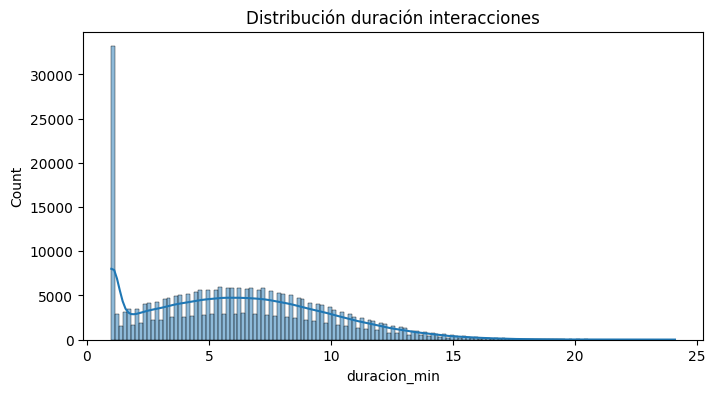

In [39]:
plt.figure(figsize=(8,4))

sns.histplot(
    soporte_churn['duracion_min'],
    kde=True
)

plt.title('Distribución duración interacciones')

plt.show()

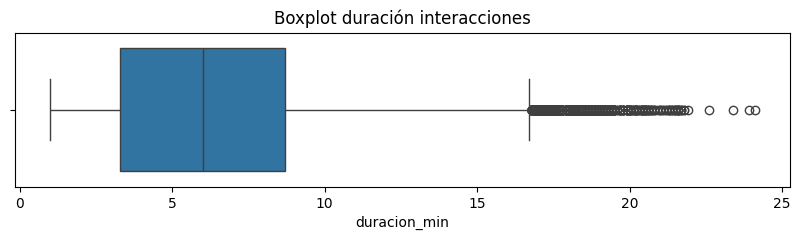

In [40]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=soporte_churn['duracion_min']
)

plt.title('Boxplot duración interacciones')

plt.show()

#### Satisfacción

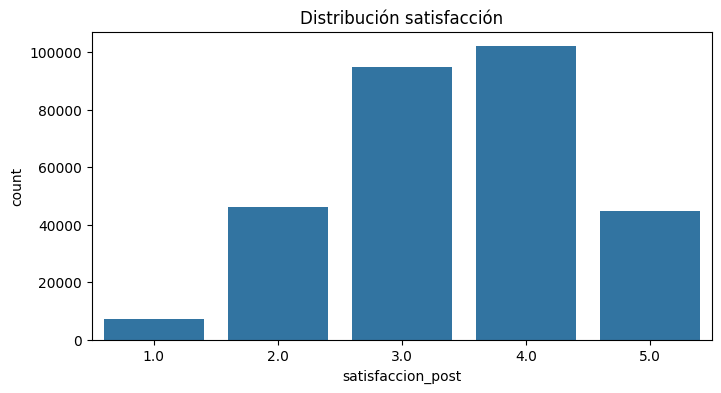

In [41]:
plt.figure(figsize=(8,4))

sns.countplot(
    data=soporte_churn,
    x='satisfaccion_post'
)

plt.title('Distribución satisfacción')

plt.show()

#### Stress calidad

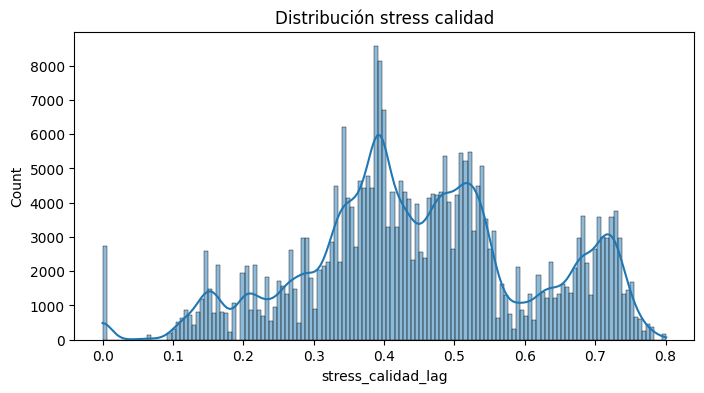

In [42]:
plt.figure(figsize=(8,4))

sns.histplot(
    soporte_churn['stress_calidad_lag'],
    kde=True
)

plt.title('Distribución stress calidad')

plt.show()

#### Días retraso

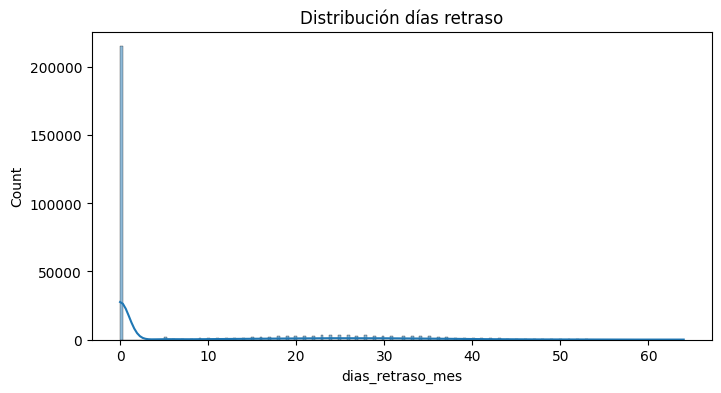

In [43]:
plt.figure(figsize=(8,4))

sns.histplot(
    soporte_churn['dias_retraso_mes'],
    kde=True
)

plt.title('Distribución días retraso')

plt.show()

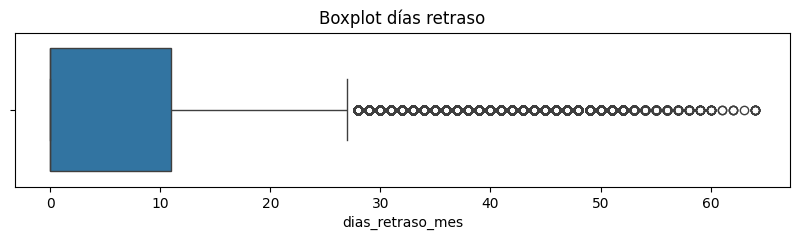

In [44]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=soporte_churn['dias_retraso_mes']
)

plt.title('Boxplot días retraso')

plt.show()

### 4.2 Variables categóricas


#### Canal

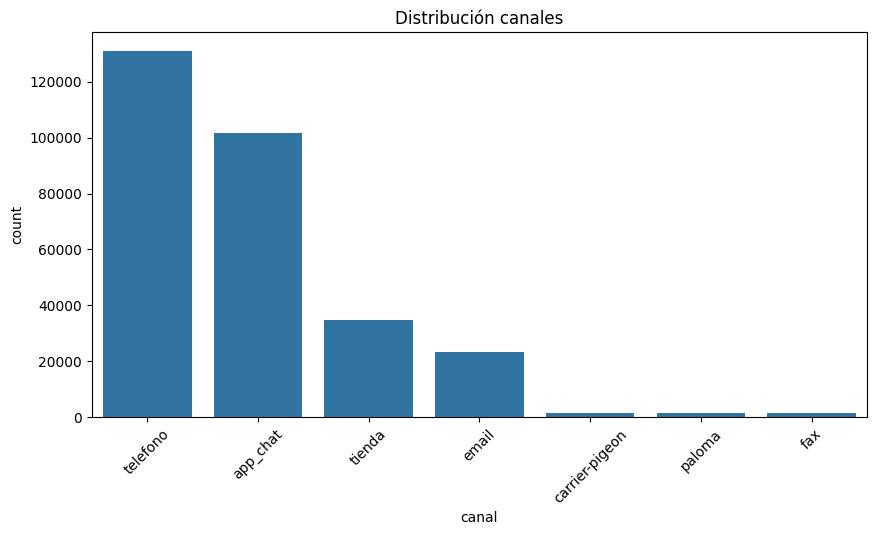

In [45]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=soporte_churn,
    x='canal',
    order=soporte_churn['canal']
        .value_counts()
        .index
)

plt.title('Distribución canales')

plt.xticks(rotation=45)

plt.show()

#### Motivo

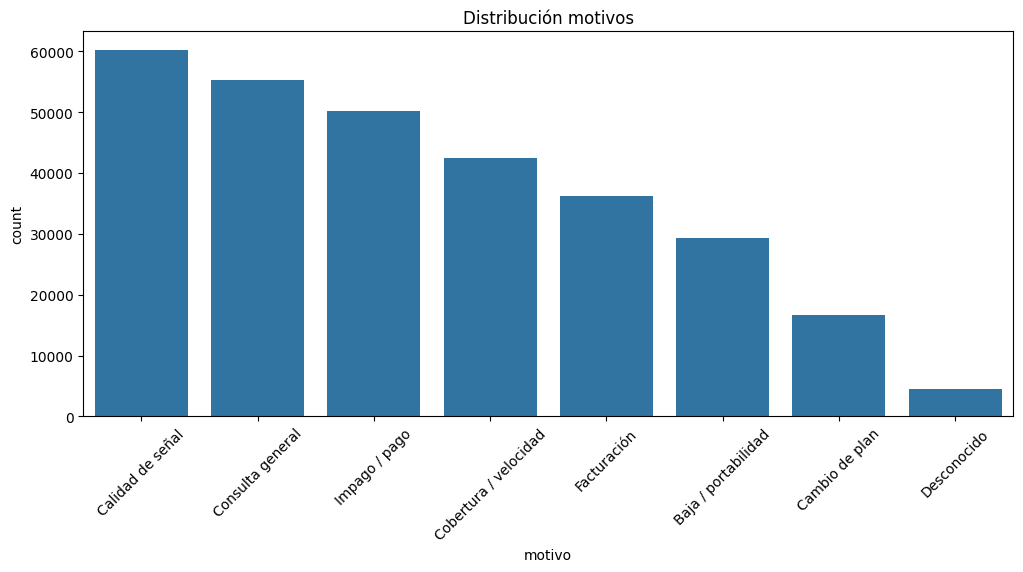

In [46]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=soporte_churn,
    x='motivo',
    order=soporte_churn['motivo']
        .value_counts()
        .index
)

plt.title('Distribución motivos')

plt.xticks(rotation=45)

plt.show()

#### Resuelto

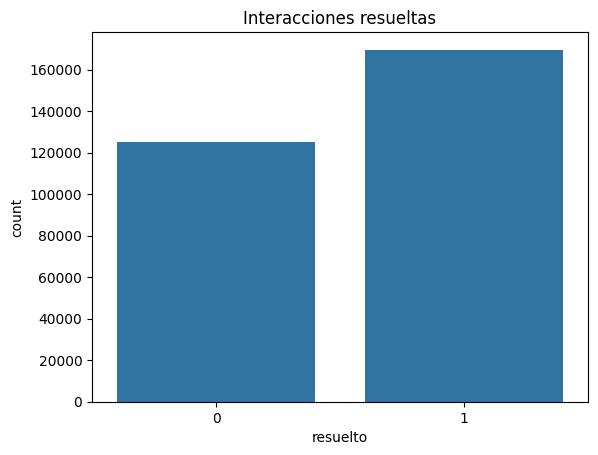

In [47]:
sns.countplot(
    data=soporte_churn,
    x='resuelto'
)

plt.title('Interacciones resueltas')

plt.show()

#### Impago

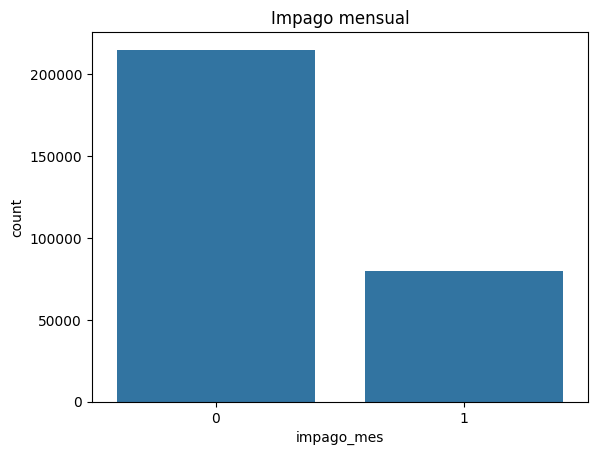

In [48]:
sns.countplot(
    data=soporte_churn,
    x='impago_mes'
)

plt.title('Impago mensual')

plt.show()

#### Churn

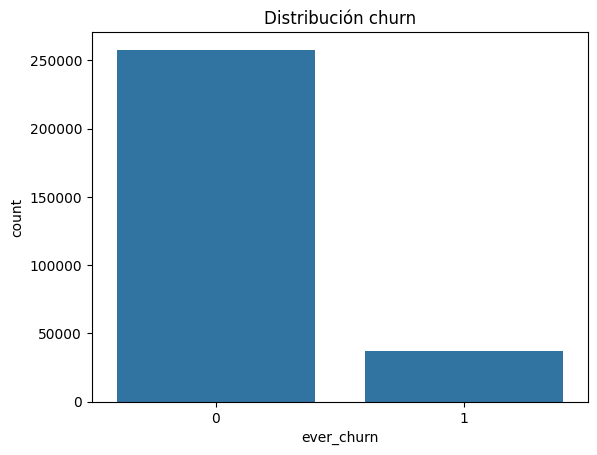

In [49]:
sns.countplot(
    data=soporte_churn,
    x='ever_churn'
)

plt.title('Distribución churn')

plt.show()

### 4.3 Variables temporales


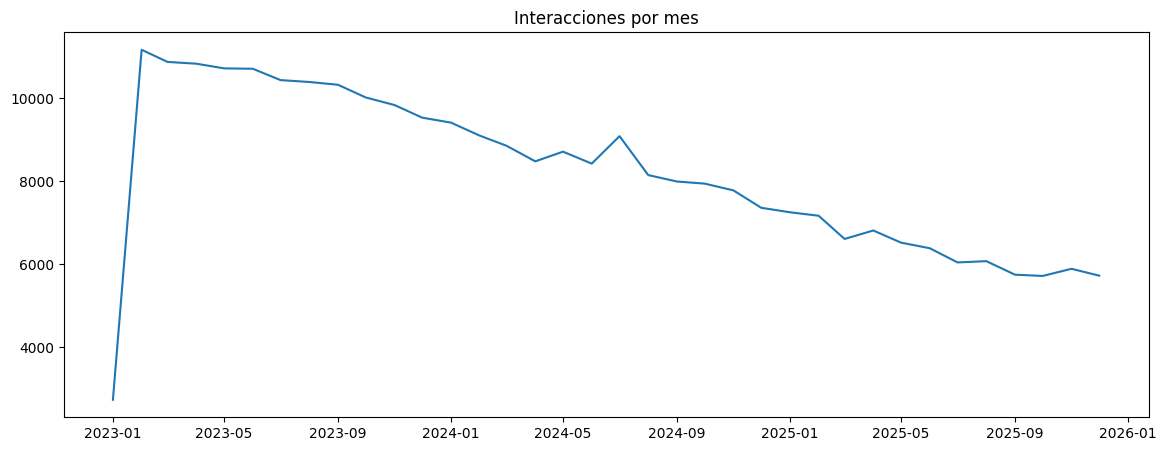

In [50]:
interacciones_mes = (
    soporte_churn
    .groupby('mes')
    .size()
)

plt.figure(figsize=(14,5))

plt.plot(
    interacciones_mes.index,
    interacciones_mes.values
)

plt.title('Interacciones por mes')

plt.show()

EXPLORAR SI HAY CORRELACION ENTRE AUMENTO DE INTERACCIONES EN EL PICO ENTRE 05/2024 Y 09/2024 Y AUMENTO DE CHURN EN ESE PERIODO

## 5. Análisis bivariante y multivariante


### 5.1 Variables numéricas vs churn


### 5.2 Variables categóricas vs churn


### 5.3 Correlaciones


### 5.4 Patrones de comportamiento


### 5.5 Variables temporales


## 6. Principales hallazgos relacionados con churn


## 7. Conclusiones

interacciones_soporte: (308487, 13)


,interaccion_id,cliente_id,fecha_evento,mes,canal,motivo,duracion_min,resuelto,satisfaccion_post,stress_calidad_lag,incidencia_masiva_lag,impago_mes,dias_retraso_mes
0,I923052492930,C000001,2023-02-07,2023-02-01,telefono,Facturación,9.5,0,4.0,0.4104,0,0,0
1,I692361171059,C000001,2023-04-20,2023-04-01,app_chat,Facturación,3.9,1,4.0,0.4301,0,0,0
2,I354109146175,C000001,2023-04-27,2023-04-01,app_chat,Baja / portabilidad,2.8,1,5.0,0.4301,0,0,0
3,I986032353420,C000001,2023-05-04,2023-05-01,telefono,Consulta general,8.4,1,3.0,0.4486,0,0,0
4,I553023863181,C000001,2023-06-26,2023-06-01,telefono,Impago / pago,4.5,1,4.0,0.3936,0,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308487 entries, 0 to 308486
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   interaccion_id         308487 non-null  object 
 1   cliente_id             308487 non-null  object 
 2   fecha_evento           308487 non-null  object 
 3   mes                    308487 non-null  object 
 4   canal                  308487 non-null  object 
 5   motivo                 303847 non-null  object 
 6   duracion_min           308487 non-null  float64
 7   resuelto               308487 non-null  int64  
 8   satisfaccion_post      303858 non-null  float64
 9   stress_calidad_lag     308487 non-null  float64
 10  incidencia_masiva_lag  308487 non-null  int64  
 11  impago_mes             308487 non-null  int64  
 12  dias_retraso_mes       308487 non-null  int64  
dtypes: float64(3), int64(4), object(6)
memory usage: 30.6+ MB
Categóricas: ['interaccion_id',

,count,mean,std,min,25%,50%,75%,max
duracion_min,308487.0,6.017850,3.935398,-20.6,3.2000,5.900,8.6000,24.1000
satisfaccion_post,303858.0,3.444882,1.004027,1.0,3.0000,3.000,4.0000,5.0000
stress_calidad_lag,308487.0,0.450733,0.161818,0.0,0.3511,0.439,0.5437,0.8009
dias_retraso_mes,308487.0,7.074013,12.767853,0.0,0.0000,0.000,11.0000,64.0000


Duplicados: 4558


...

resuelto
1    177417
0    131070
Name: count, dtype: int64



impago_mes


impago_mes
0    225044
1     83443
Name: count, dtype: int64



incidencia_masiva_lag


incidencia_masiva_lag
0    306411
1      2076
Name: count, dtype: int64

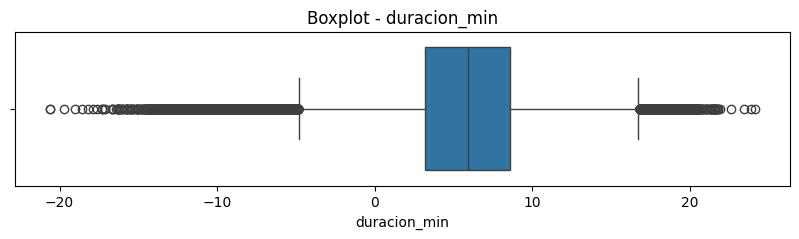

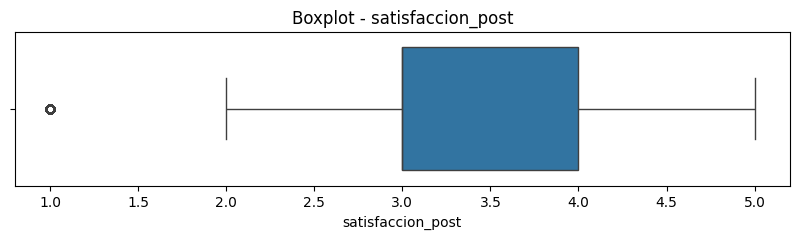

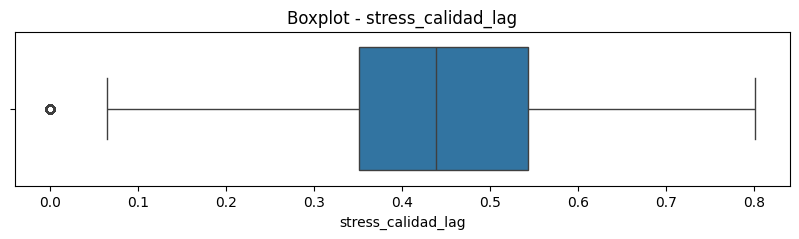

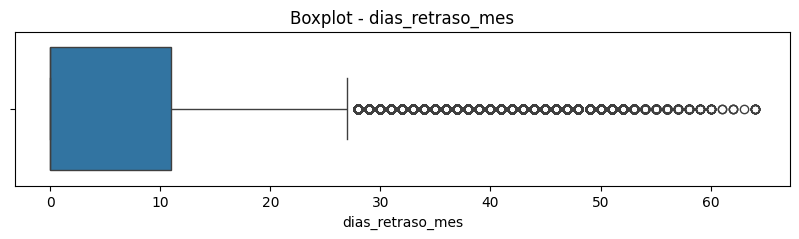

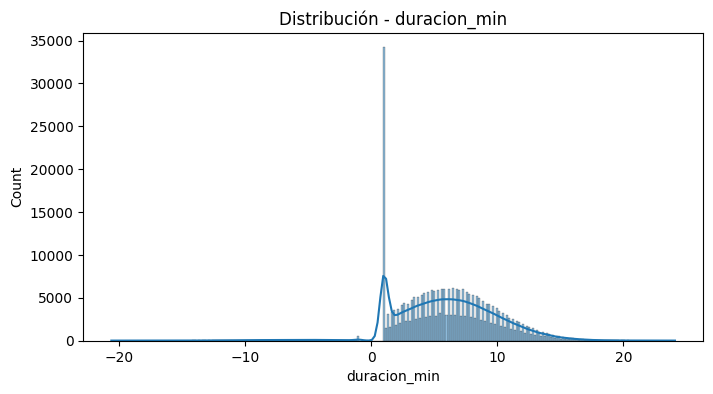

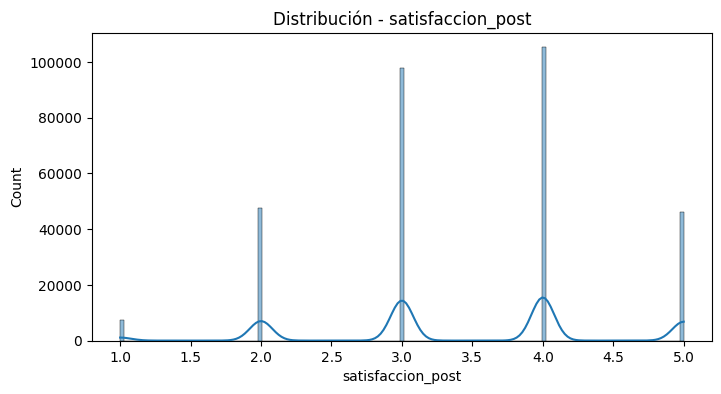

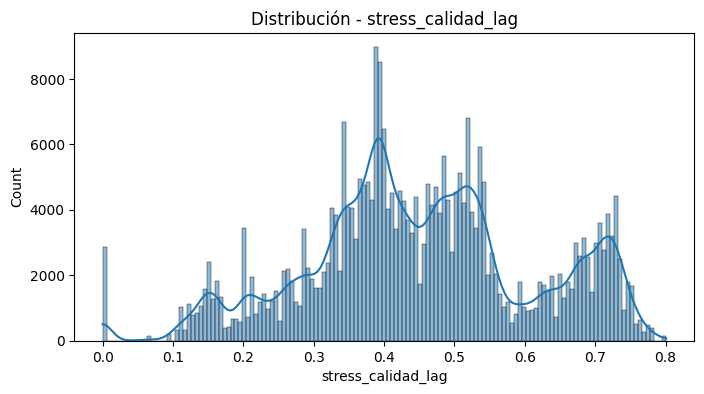

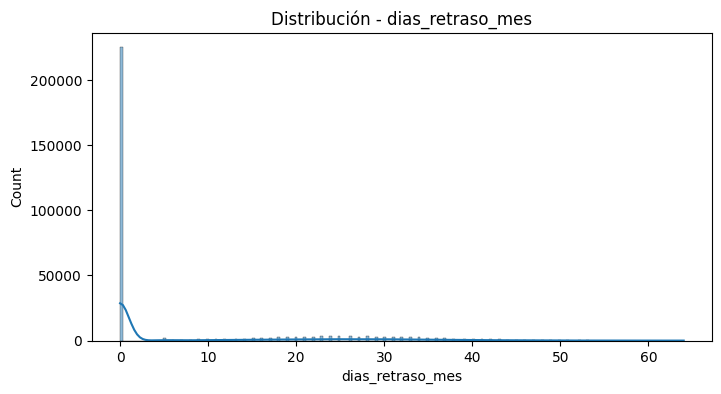

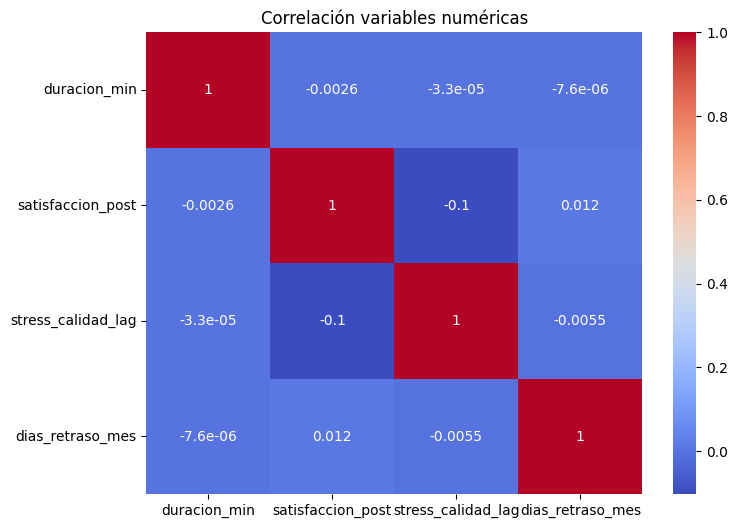

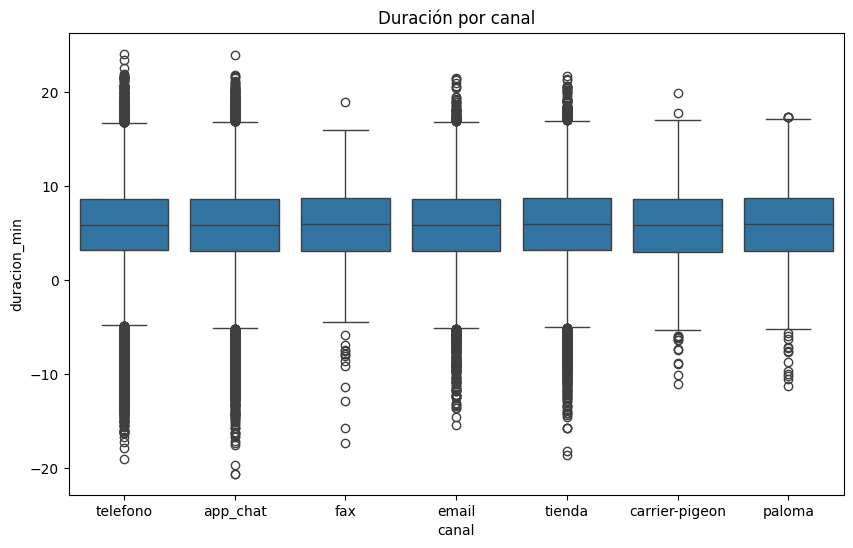

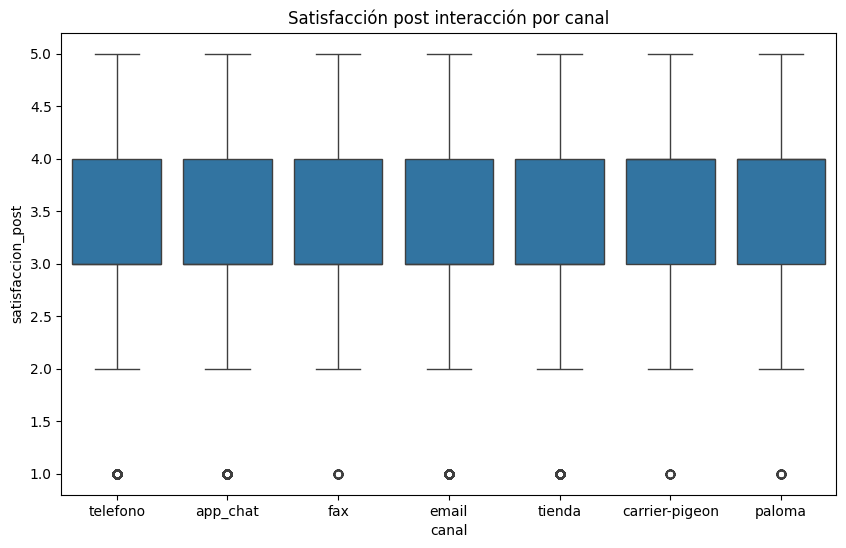

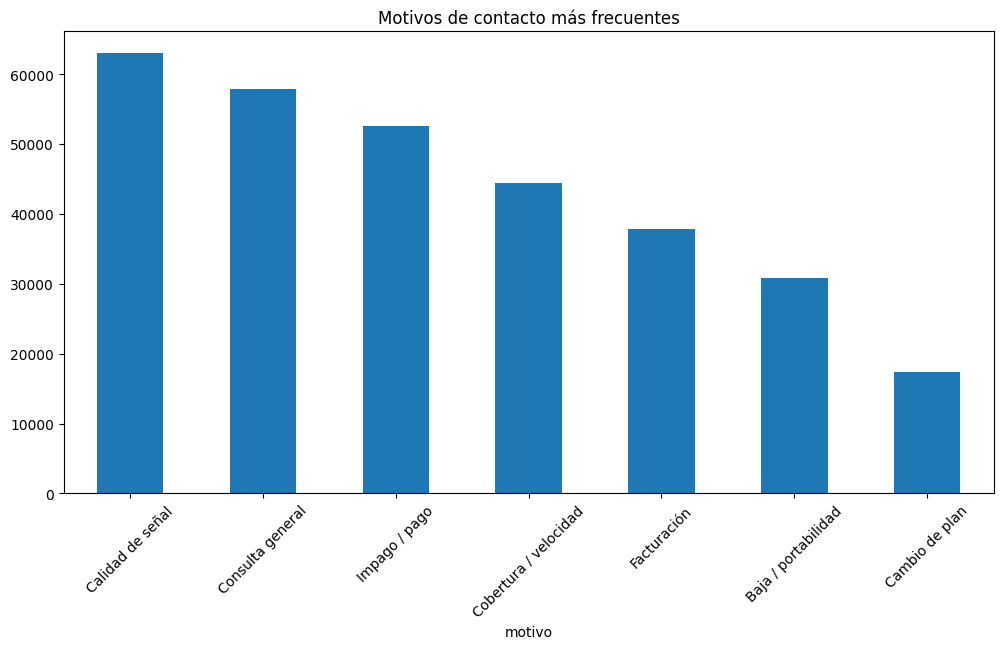

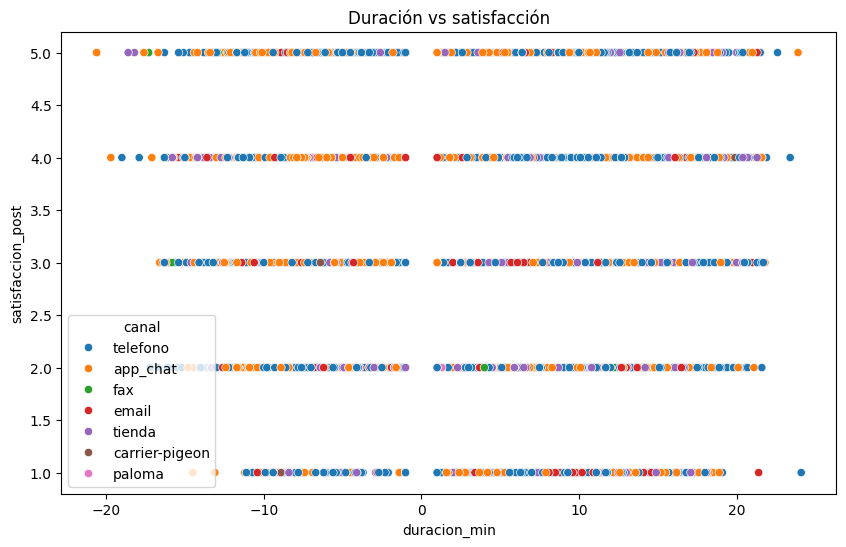

cliente_id
C005384    84
C008164    79
C004160    79
C008291    78
C004938    78
C003079    77
C000351    76
C007513    73
C002323    73
C009509    73
Name: count, dtype: int64

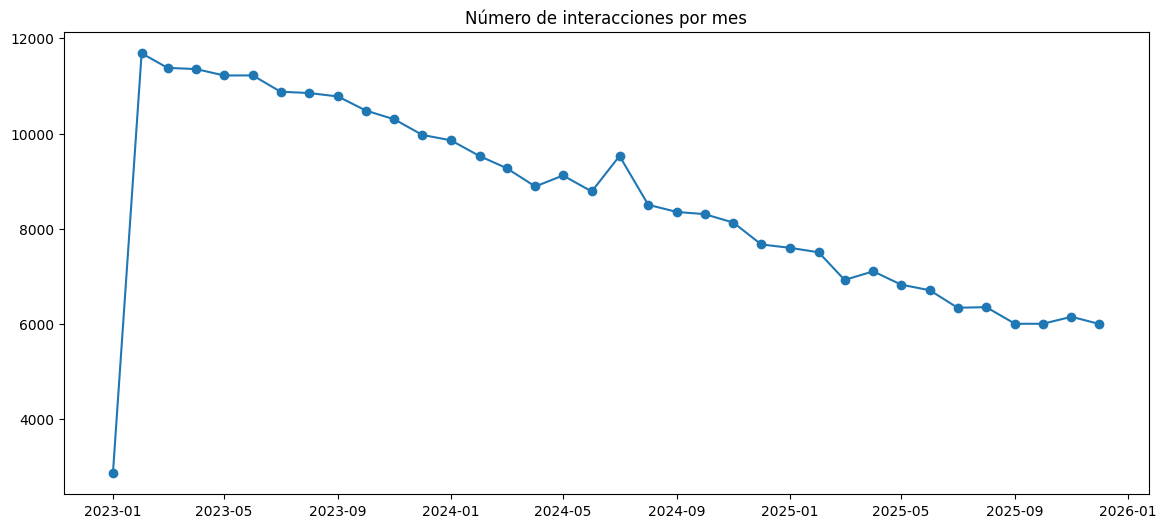

In [9]:
# ==========================================
# EDA - Interacciones con soporte
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Cargar dataset
# ==========================================

path_soporte = r'C:\Users\cunat\Desktop\GIT\UCV-Churn\data\raw\interacciones_soporte.csv'

soporte = pd.read_csv(path_soporte)

print('interacciones_soporte:', soporte.shape)

display(soporte.head())


# ==========================================
# Información general
# ==========================================

soporte.info()


# ==========================================
# Conversión de fechas
# ==========================================

soporte['fecha_evento'] = pd.to_datetime(
    soporte['fecha_evento'],
    format='mixed'
)

soporte['mes'] = pd.to_datetime(
    soporte['mes'],
    format='mixed'
)


# ==========================================
# Separación de variables
# ==========================================

soporte_cat_cols = [
    'interaccion_id',
    'cliente_id',
    'canal',
    'motivo',
    'resuelto',
    'incidencia_masiva_lag',
    'impago_mes'
]

soporte_num_cols = [
    'duracion_min',
    'satisfaccion_post',
    'stress_calidad_lag',
    'dias_retraso_mes'
]

soporte_date_cols = [
    'fecha_evento',
    'mes'
]

print('Categóricas:', soporte_cat_cols)
print('Numéricas:', soporte_num_cols)
print('Temporales:', soporte_date_cols)


# ==========================================
# Descriptivo numérico
# ==========================================

display(
    soporte[soporte_num_cols]
    .describe()
    .T
)


# ==========================================
# Duplicados
# ==========================================

print(
    'Duplicados:',
    soporte.duplicated().sum()
)

duplicados = soporte[
    soporte.duplicated(keep=False)
]

display(duplicados)


# ==========================================
# Valores nulos
# ==========================================

display(
    soporte.isnull().sum()
)


# ==========================================
# Distribución variables categóricas
# ==========================================

for col in [
    'canal',
    'motivo',
    'resuelto',
    'impago_mes',
    'incidencia_masiva_lag'
]:
    
    print('\n')
    print(col)
    
    display(
        soporte[col]
        .value_counts(dropna=False)
    )


# ==========================================
# Boxplots variables numéricas
# ==========================================

for col in soporte_num_cols:
    
    plt.figure(figsize=(10,2))
    
    sns.boxplot(
        x=soporte[col]
    )
    
    plt.title(f'Boxplot - {col}')
    
    plt.show()


# ==========================================
# Histograms variables numéricas
# ==========================================

for col in soporte_num_cols:
    
    plt.figure(figsize=(8,4))
    
    sns.histplot(
        soporte[col],
        kde=True
    )
    
    plt.title(f'Distribución - {col}')
    
    plt.show()


# ==========================================
# Correlación
# ==========================================

plt.figure(figsize=(8,6))

sns.heatmap(
    soporte[soporte_num_cols]
    .corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlación variables numéricas')

plt.show()


# ==========================================
# Análisis por canal
# ==========================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=soporte,
    x='canal',
    y='duracion_min'
)

plt.title('Duración por canal')

plt.show()


# ==========================================
# Satisfacción por canal
# ==========================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=soporte,
    x='canal',
    y='satisfaccion_post'
)

plt.title('Satisfacción post interacción por canal')

plt.show()


# ==========================================
# Motivos más frecuentes
# ==========================================

plt.figure(figsize=(12,6))

soporte['motivo'] \
    .value_counts() \
    .plot(kind='bar')

plt.title('Motivos de contacto más frecuentes')

plt.xticks(rotation=45)

plt.show()


# ==========================================
# Relación duración vs satisfacción
# ==========================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=soporte,
    x='duracion_min',
    y='satisfaccion_post',
    hue='canal'
)

plt.title('Duración vs satisfacción')

plt.show()


# ==========================================
# Clientes con más interacciones
# ==========================================

top_clientes = (
    soporte['cliente_id']
    .value_counts()
    .head(10)
)

display(top_clientes)


# ==========================================
# Evolución temporal interacciones
# ==========================================

interacciones_mes = (
    soporte
    .groupby('mes')
    .size()
)

plt.figure(figsize=(14,6))

plt.plot(
    interacciones_mes.index,
    interacciones_mes.values,
    marker='o'
)

plt.title('Número de interacciones por mes')

plt.show()

# PRUEBA

In [10]:
# ==========================================
# Agregación de métricas por cliente
# ==========================================

cliente_features = (
    soporte_churn
    .groupby('cliente_id')
    .agg({
        'duracion_min': ['mean', 'max', 'count'],
        'satisfaccion_post': 'mean',
        'stress_calidad_lag': 'mean',
        'dias_retraso_mes': 'mean',
        'resuelto': 'mean',
        'impago_mes': 'max',
        'incidencia_masiva_lag': 'max',
        'ever_churn': 'max'
    })
)

cliente_features.columns = [
    '_'.join(col).strip()
    for col in cliente_features.columns.values
]

cliente_features = cliente_features.reset_index()

display(cliente_features.head())

,cliente_id,duracion_min_mean,duracion_min_max,duracion_min_count,satisfaccion_post_mean,stress_calidad_lag_mean,dias_retraso_mes_mean,resuelto_mean,impago_mes_max,incidencia_masiva_lag_max,ever_churn_max
0,C000001,6.100000,11.6,23,3.500000,0.321265,11.304348,0.521739,1,0,0
1,C000002,6.776316,17.3,38,3.578947,0.487266,13.947368,0.684211,1,0,0
2,C000003,5.125581,11.4,43,3.604651,0.479840,9.813953,0.720930,1,1,1
3,C000004,5.383784,10.7,37,3.750000,0.470754,6.540541,0.648649,1,0,0
4,C000005,5.629412,12.1,34,3.575758,0.449603,5.500000,0.647059,1,0,0


In [11]:
# Canal más frecuente

canal_mode = (
    soporte_churn
    .groupby('cliente_id')['canal']
    .agg(lambda x: x.mode()[0])
    .reset_index()
)

# Motivo más frecuente

motivo_mode = (
    soporte_churn
    .groupby('cliente_id')['motivo']
    .agg(lambda x: x.mode()[0])
    .reset_index()
)

# Unión

cliente_features = cliente_features.merge(
    canal_mode,
    on='cliente_id',
    how='left'
)

cliente_features = cliente_features.merge(
    motivo_mode,
    on='cliente_id',
    how='left'
)

display(cliente_features.head())

,cliente_id,duracion_min_mean,duracion_min_max,duracion_min_count,satisfaccion_post_mean,stress_calidad_lag_mean,dias_retraso_mes_mean,resuelto_mean,impago_mes_max,incidencia_masiva_lag_max,ever_churn_max,canal,motivo
0,C000001,6.100000,11.6,23,3.500000,0.321265,11.304348,0.521739,1,0,0,telefono,Baja / portabilidad
1,C000002,6.776316,17.3,38,3.578947,0.487266,13.947368,0.684211,1,0,0,telefono,Impago / pago
2,C000003,5.125581,11.4,43,3.604651,0.479840,9.813953,0.720930,1,1,1,telefono,Impago / pago
3,C000004,5.383784,10.7,37,3.750000,0.470754,6.540541,0.648649,1,0,0,app_chat,Consulta general
4,C000005,5.629412,12.1,34,3.575758,0.449603,5.500000,0.647059,1,0,0,app_chat,Consulta general


In [12]:
# ==========================================
# Variables predictoras y target
# ==========================================

X = cliente_features.drop(
    columns=[
        'cliente_id',
        'ever_churn_max'
    ]
)

y = cliente_features['ever_churn_max']

In [13]:
# ==========================================
# One Hot Encoding
# ==========================================

X = pd.get_dummies(
    X,
    drop_first=True
)

print(X.shape)

(9973, 18)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(7978, 18)
(1995, 18)


In [15]:
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

# ==========================================
# Modelo
# ==========================================

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

# ==========================================
# KFold
# ==========================================

kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=kfold,
    scoring='roc_auc'
)

print('ROC-AUC CV:')
print(cv_scores)

print('\nMean ROC-AUC:')
print(cv_scores.mean())

ROC-AUC CV:
[0.91480914 0.92073279 0.92045837 0.9034995  0.91488591]

Mean ROC-AUC:
0.9148771426687764


In [16]:
# ==========================================
# Entrenamiento final
# ==========================================

xgb_model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, gpu_id=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, predictor=None, random_state=42, ...)

In [17]:
# ==========================================
# Predicciones
# ==========================================

y_pred = xgb_model.predict(X_test)

y_pred_proba = xgb_model.predict_proba(X_test)[:,1]

In [18]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print('Accuracy:')
print(
    accuracy_score(y_test, y_pred)
)

print('\nROC-AUC:')
print(
    roc_auc_score(y_test, y_pred_proba)
)

print('\nClassification Report:')
print(
    classification_report(y_test, y_pred)
)

Accuracy:
0.9353383458646617

ROC-AUC:
0.9381772151898735

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      1600
           1       0.94      0.72      0.81       395

    accuracy                           0.94      1995
   macro avg       0.94      0.85      0.89      1995
weighted avg       0.94      0.94      0.93      1995



In [19]:
import sys

print(sys.executable)

c:\Users\cunat\Desktop\GIT\UCV-Churn\venv\Scripts\python.exe
